In [1]:
from pathlib import Path 
import mne
from numpy.typing import NDArray

def get_Xy(p_raw : str | None = None,
           p_annot : str | None = None) -> tuple[mne.io.BaseRaw, NDArray]:
    path = Path("/Users/jean-baptistechaudron/Documents/Freelance/SleepLab/data/mock/sleep_data/physionet-sleep-data")
    
    
    if p_raw:
        path_raw = path/p_raw 
    else:
        path_raw = path/"SC4001E0-PSG.edf" 

    if p_annot:
        path_annot = path/p_annot
    else:
        path_annot = path/"SC4001EC-Hypnogram.edf"

    raw = mne.io.read_raw_edf(path_raw)
    annotations = mne.read_annotations(path_annot)
    raw.set_annotations(annotations,
                        emit_warning=False)
    
    annotation_desc_2_event_id = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3": 4,
    "Sleep stage 4": 4,
    "Sleep stage R": 5,
    }

    events, a = mne.events_from_annotations(
        raw, event_id = annotation_desc_2_event_id, chunk_duration=30.0
    )

    return raw, events


In [2]:
raw, y = get_Xy()

Extracting EDF parameters from /Users/jean-baptistechaudron/Documents/Freelance/SleepLab/data/mock/sleep_data/physionet-sleep-data/SC4001E0-PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


/var/folders/y7/kr_2pgf94kz_wtft4h64r_yh0000gn/T/ipykernel_71145/177410315.py:20: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(path_raw)
/var/folders/y7/kr_2pgf94kz_wtft4h64r_yh0000gn/T/ipykernel_71145/177410315.py:20: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(path_raw)
/var/folders/y7/kr_2pgf94kz_wtft4h64r_yh0000gn/T/ipykernel_71145/177410315.py:20: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(path_raw)


Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]


In [3]:
raw.ch_names

['EEG Fpz-Cz',
 'EEG Pz-Oz',
 'EOG horizontal',
 'Resp oro-nasal',
 'EMG submental',
 'Temp rectal',
 'Event marker']

In [20]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: 1989-04-24 16:13:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 2, first_name: Female, last_name: 33yr>
>

In [5]:
epoch = mne.Epochs(raw,events=y,tmin=0, tmax=30, baseline=None,picks=["EEG Fpz-Cz"])

Not setting metadata
2650 matching events found
No baseline correction applied
0 projection items activated


In [18]:
data = epoch.get_data()

Loading data for 2649 events and 3001 original time points ...


In [19]:
y = y[:-1,2]
data[y==2,0,:].shape

(58, 3001)

In [55]:
from event_detection import splindle_detection, K_complex_detection

data_splindle = data[y==3,0,:]
splindes = splindle_detection(data_splindle[2], sampling_frequency=100)

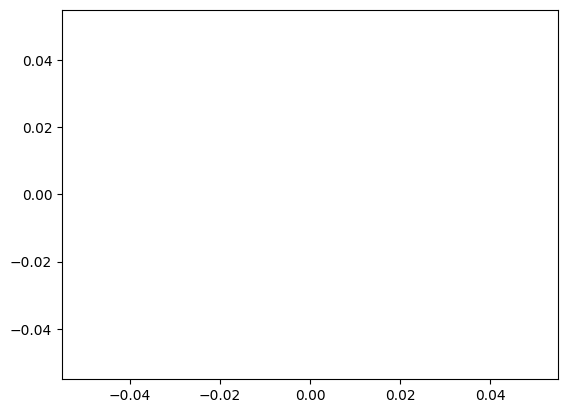

In [41]:
import matplotlib.pyplot as plt 
data_plot = data_splindle[1][:len(splindes)]
plt.plot(data_plot[splindes])

In [56]:
import numpy as np
np.where(splindes)

(array([], dtype=int64),)

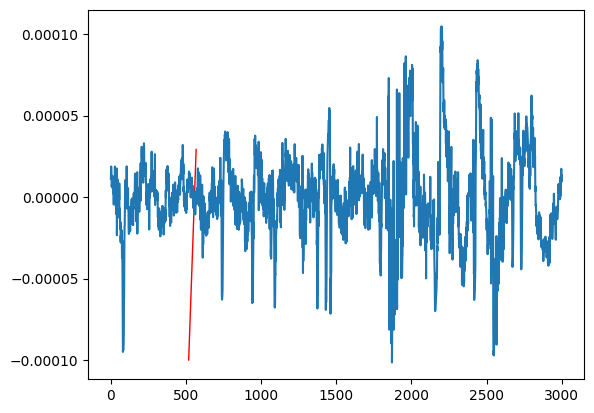

In [54]:
plt.plot(data_splindle[1])
plt.fill_between([514,564],[-0.0001,0.00003],[-0.0001,0.00003],alpha=1,color="Red")

In [78]:
import numpy as np

def spindles_detect(x, sf, thresh=0.25, wlt_params={'nc': 12, 'cf': 'auto'}):
    """Simple spindles detector based on Morlet wavelet.

    Parameters
    ----------
    x : 1D-array
        EEG signal
    sf : float
        Sampling frequency
    thresh : float
        Threshold (0 - 1)
    wlt_params : dict
        Morlet wavelet parameters ::

        'nc' : number of oscillations
        'cf' : central frequency (int or 'auto')

    Returns
    -------
    supra_thresh_bool : 1D-array (boolean)
        Boolean array indicating for each point if it is a spindles or not.
    sp_params : dict
        Spindles parameters dictionnary.
    """
    from scipy.signal import detrend
    from mne.time_frequency import morlet, psd_array_multitaper

    if wlt_params['cf'] == 'auto':
        # Compute the power spectrum and find the peak 11-16 Hz frequency.
        psd, freqs = psd_array_multitaper(x, sf, fmin=11, fmax=16, verbose=0)
        wlt_params['cf'] = freqs[np.argmax(psd)]
        print('Central frequency: %.2f Hz' % wlt_params['cf'])

    # Compute the wavelet and convolve with data
    wlt = morlet(sf, [wlt_params['cf']], n_cycles=wlt_params['nc'])[0]
    analytic = np.convolve(x, wlt, mode='same')
    phase = np.angle(analytic)

    # Square and normalize the magnitude from 0 to 1 (using the min and max)
    power = np.square(np.abs(analytic))
    norm_power = (power - power.min()) / (power.max() - power.min())

    # Find supra-threshold values and indices
    supra_thresh_bool = norm_power >= thresh
    supra_thresh_idx = np.where(supra_thresh_bool)[0]

    # Extract duration, frequency and amplitude of spindles
    sp = np.split(supra_thresh_idx, np.where(np.diff(supra_thresh_idx) != 1)[0] + 1)
    idx_start_end = np.array([[k[0], k[-1]] for k in sp])
    sp_dur = (np.diff(idx_start_end, axis=1) / sf).flatten() * 1000
    sp_amp, sp_freq = np.zeros(len(sp)), np.zeros(len(sp))
    for i in range(len(sp)):
        sp_amp[i] = np.ptp(detrend(x[sp[i]]))
        sp_freq[i] = np.median((sf / (2 * np.pi) * np.diff(phase[sp[i]])))

    sp_params = {'Duration (ms)' : sp_dur, 'Frequency (Hz)': sp_freq,
                 'Amplitude (uV)': sp_amp}

    return supra_thresh_bool, sp_params


# Run the function
#x = np.loadtxt('data_spindles_15s_200Hz.txt')
x = data[y==2,0,:][0]
sf = 100
masks, infos = spindles_detect(x, sf, thresh=0.25)

Central frequency: 11.86 Hz


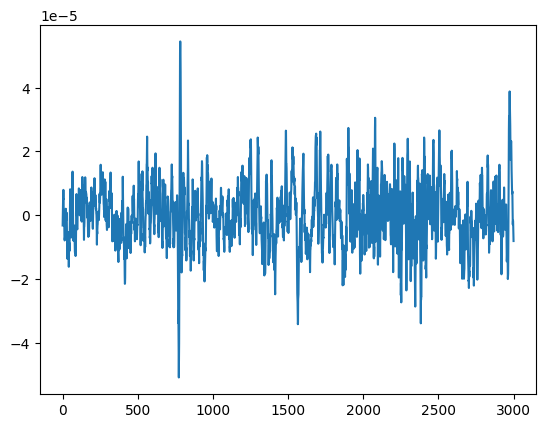

In [62]:
plt.plot(x)

In [64]:
np.where(mask)

(array([1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909,
        1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920,
        1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931,
        1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942,
        1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953,
        1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964,
        1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975,
        1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
        1987, 1988, 2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074,
        2075, 2076, 2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085,
        2086, 2087, 2088, 2089, 2090, 2091, 2092, 2093, 2094, 2095, 2096,
        2097, 2098, 2099, 2100, 2101, 2102, 2103, 2104, 2105, 2106, 2130,
        2131, 2132, 2133, 2134, 2135, 2136, 2137, 2138, 2139, 2140, 2141,
        2142, 2143, 2144, 2145, 2146, 

In [79]:
onset = []
activated = False
for e,mask in enumerate(masks):
    if mask:
        if activated:
            continue
        else:
            onset.append(e)
            activated = True
    else:
        activated = False

onset

[121, 240, 270, 651, 1337, 1427, 1731, 1929, 2069]

In [77]:
np.where(masks)

(array([1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909,
        1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920,
        1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931,
        1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942,
        1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953,
        1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964,
        1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975,
        1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
        1987, 1988, 2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074,
        2075, 2076, 2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085,
        2086, 2087, 2088, 2089, 2090, 2091, 2092, 2093, 2094, 2095, 2096,
        2097, 2098, 2099, 2100, 2101, 2102, 2103, 2104, 2105, 2106, 2130,
        2131, 2132, 2133, 2134, 2135, 2136, 2137, 2138, 2139, 2140, 2141,
        2142, 2143, 2144, 2145, 2146, 

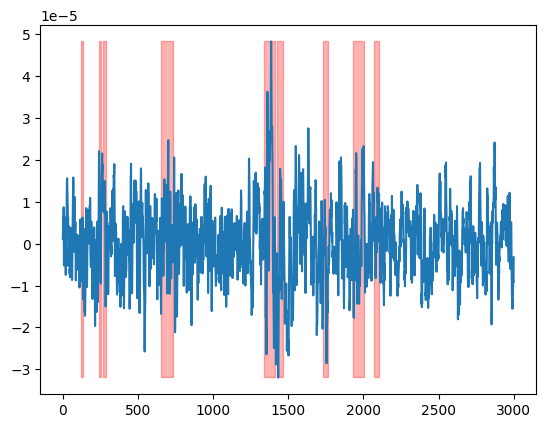

In [80]:
from matplotlib.patches import Rectangle

duration = infos["Duration (ms)"]

fig, ax = plt.subplots()
ax.plot(x)

for ons, dur in zip(onset, duration):
    start = ons
    end = ons+dur/10
    ymin = min(x)
    ymax = max(x)

    # Use Rectangle patch
    rect = Rectangle((start, ymin), end - start, ymax - ymin, color='red', alpha=0.3)
    ax.add_patch(rect)
